# freezing 12/7

In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
pre=100
post=100
session_path = '../data/co6/co6_10122023'
session2_path = '../data/vgat2_06062023'
session = MPOptoClass(session_path, post=post)
session2 = MPOptoClass(session2_path, post=post, experiment='not CO')

love
love


# co6, 10/12/23

# 0. predicting CFA using just CFA PCs.

In [3]:
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds)

(session.X, session.Y), pca_objs  = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)
test = copy.deepcopy(session.X)
session.X_CFA = session.X[:, :session.num_CFA*10]
session.Y_CFA = session.Y[:, :session.num_CFA]

session.X_RFA = session.X[:, session.num_CFA*10:]
session.Y_RFA = session.Y[:, session.num_CFA:]


session.X_ctrl, session.Y_ctrl = session.transformat(pca_objs, bounds=psth_ctrl_bounds)
session.X_CFA_ctrl = session.X_ctrl[:, :session.num_CFA*10]
session.Y_CFA_ctrl = session.Y_ctrl[:, :session.num_CFA]

session.X_RFA_ctrl = session.X_ctrl[:, session.num_CFA*10:]
session.Y_RFA_ctrl = session.Y_ctrl[:, session.num_CFA:]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


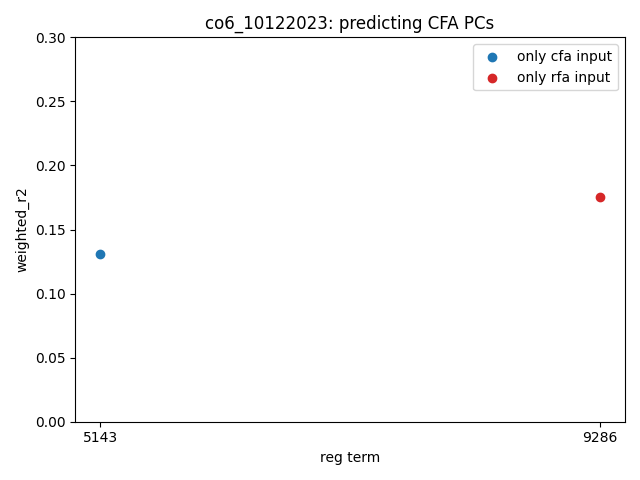

In [4]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session.X_CFA, session.Y_CFA, C=c)
    h_rfa = train_wiener_filter(session.X_RFA, session.Y_CFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session.Y_CFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session.Y_CFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig0, ax0 = plt.subplots()
ax0.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax0.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax0.set_title(f'{session.name}: predicting CFA PCs')
ax0.set_ylim([0,.3])
ax0.set_xlabel('reg term')
ax0.set_ylabel('weighted_r2')
ax0.legend()
fig0.tight_layout()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


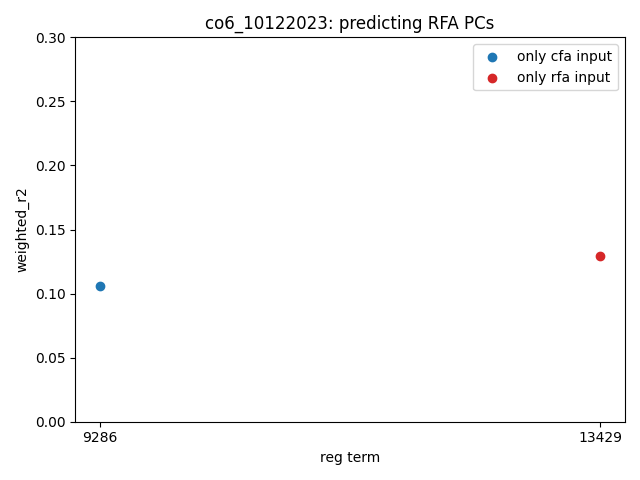

In [5]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session.X_CFA, session.Y_RFA, C=c)
    h_rfa = train_wiener_filter(session.X_RFA, session.Y_RFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session.Y_RFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session.Y_RFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig01, ax01 = plt.subplots()
ax01.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax01.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax01.set_title(f'{session.name}: predicting RFA PCs')
ax01.set_ylim([0,.3])
ax01.set_xlabel('reg term')
ax01.set_ylabel('weighted_r2')
ax01.legend()
fig01.tight_layout()

In [6]:
psth_bounds = copy.deepcopy(session2.laser['laser_bounds'])
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session2.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session2.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds)

(session2.X, session2.Y), pca_objs  = session2.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)
test = copy.deepcopy(session2.X)
session2.X_CFA = session2.X[:, :session2.num_CFA*10]
session2.Y_CFA = session2.Y[:, :session2.num_CFA]

session2.X_RFA = session2.X[:, session2.num_CFA*10:]
session2.Y_RFA = session2.Y[:, session2.num_CFA:]


session2.X_ctrl, session2.Y_ctrl = session2.transformat(pca_objs, bounds=psth_ctrl_bounds)
session2.X_CFA_ctrl = session2.X_ctrl[:, :session2.num_CFA*10]
session2.Y_CFA_ctrl = session2.Y_ctrl[:, :session2.num_CFA]

session2.X_RFA_ctrl = session2.X_ctrl[:, session2.num_CFA*10:]
session2.Y_RFA_ctrl = session2.Y_ctrl[:, session2.num_CFA:]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


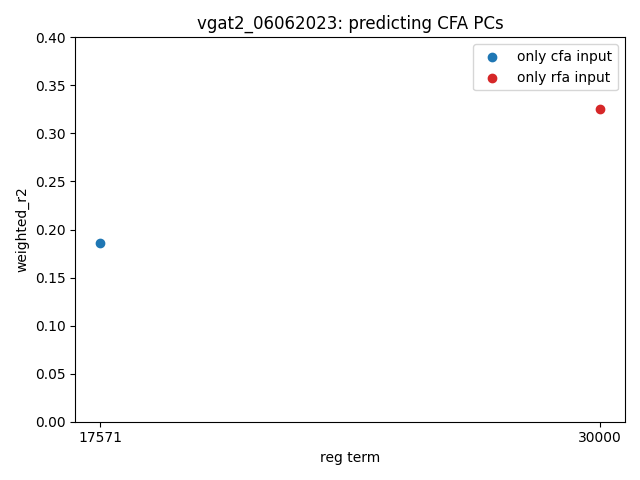

In [7]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session2.X_CFA, session2.Y_CFA, C=c)
    h_rfa = train_wiener_filter(session2.X_RFA, session2.Y_CFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session2.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session2.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session2.Y_CFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session2.Y_CFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig02, ax02 = plt.subplots()
ax02.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax02.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax02.set_title(f'{session2.name}: predicting CFA PCs')
ax02.set_ylim([0,.4])
ax02.set_xlabel('reg term')
ax02.set_ylabel('weighted_r2')
ax02.legend()
fig02.tight_layout()



/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


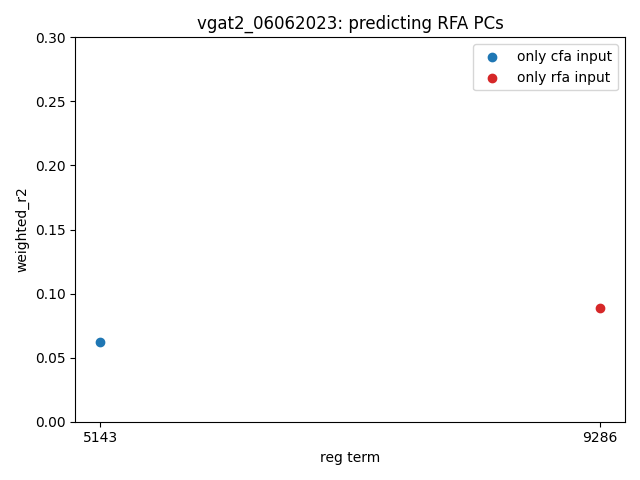

In [8]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session2.X_CFA, session2.Y_RFA, C=c)
    h_rfa = train_wiener_filter(session2.X_RFA, session2.Y_RFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session2.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session2.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session2.Y_RFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session2.Y_RFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig03, ax03 = plt.subplots()
ax03.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax03.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax03.set_title(f'{session2.name}: predicting RFA PCs')
ax03.set_ylim([0,.3])
ax03.set_xlabel('reg term')
ax03.set_ylabel('weighted_r2')
ax03.legend()
fig03.tight_layout()



# subsampling RFA neurons

In [9]:
rfa_sample = np.random.choice(session.num_RFA, session.num_CFA, replace=False)
rfa_sample.shape

new_RFA_train = []
for sample in rfa_sample:
    new_RFA_train.append(session.RFA['train'][sample])
    
session.RFA['train'] = new_RFA_train
session.num_RFA = len(session.RFA['train'])

In [10]:
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds)

(session.X, session.Y), pca_objs  = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)
test = copy.deepcopy(session.X)
session.X_CFA = session.X[:, :session.num_CFA*10]
session.Y_CFA = session.Y[:, :session.num_CFA]

session.X_RFA = session.X[:, session.num_CFA*10:]
session.Y_RFA = session.Y[:, session.num_CFA:]


session.X_ctrl, session.Y_ctrl = session.transformat(pca_objs, bounds=psth_ctrl_bounds)
session.X_CFA_ctrl = session.X_ctrl[:, :session.num_CFA*10]
session.Y_CFA_ctrl = session.Y_ctrl[:, :session.num_CFA]

session.X_RFA_ctrl = session.X_ctrl[:, session.num_CFA*10:]
session.Y_RFA_ctrl = session.Y_ctrl[:, session.num_CFA:]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


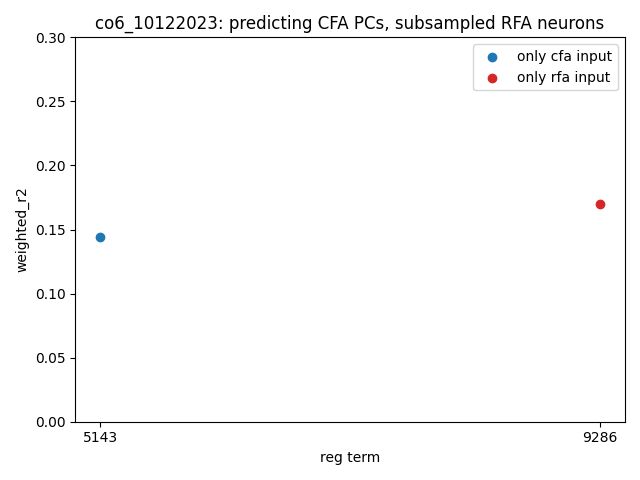

In [11]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session.X_CFA, session.Y_CFA, C=c)
    h_rfa = train_wiener_filter(session.X_RFA, session.Y_CFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session.Y_CFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session.Y_CFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig1, ax1 = plt.subplots()
ax1.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax1.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax1.set_title(f'{session.name}: predicting CFA PCs, subsampled RFA neurons')
ax1.set_ylim([0,.3])
ax1.set_xlabel('reg term')
ax1.set_ylabel('weighted_r2')
ax1.legend()
fig1.tight_layout()

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


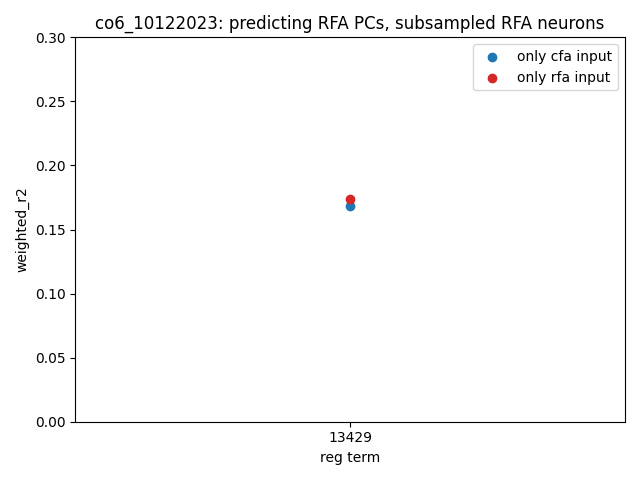

In [12]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session.X_CFA, session.Y_RFA, C=c)
    h_rfa = train_wiener_filter(session.X_RFA, session.Y_RFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session.Y_RFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session.Y_RFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig11, ax11 = plt.subplots()
ax11.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax11.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax11.set_title(f'{session.name}: predicting RFA PCs, subsampled RFA neurons')
ax11.set_ylim([0,.3])
ax11.set_xlabel('reg term')
ax11.set_ylabel('weighted_r2')
ax11.legend()
fig11.tight_layout()

In [13]:
rfa_sample = np.random.choice(session2.num_RFA, session2.num_CFA, replace=False)
rfa_sample.shape

new_RFA_train = []
for sample in rfa_sample:
    new_RFA_train.append(session2.RFA['train'][sample])
    
session2.RFA['train'] = new_RFA_train
session2.num_RFA = len(session2.RFA['train'])

In [14]:
psth_bounds = copy.deepcopy(session2.laser['laser_bounds'])
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session2.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session2.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds)

(session2.X, session2.Y), pca_objs  = session2.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)
test = copy.deepcopy(session2.X)
session2.X_CFA = session2.X[:, :session2.num_CFA*10]
session2.Y_CFA = session2.Y[:, :session2.num_CFA]

session2.X_RFA = session2.X[:, session2.num_CFA*10:]
session2.Y_RFA = session2.Y[:, session2.num_CFA:]


session2.X_ctrl, session2.Y_ctrl = session2.transformat(pca_objs, bounds=psth_ctrl_bounds)
session2.X_CFA_ctrl = session2.X_ctrl[:, :session2.num_CFA*10]
session2.Y_CFA_ctrl = session2.Y_ctrl[:, :session2.num_CFA]

session2.X_RFA_ctrl = session2.X_ctrl[:, session2.num_CFA*10:]
session2.Y_RFA_ctrl = session2.Y_ctrl[:, session2.num_CFA:]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


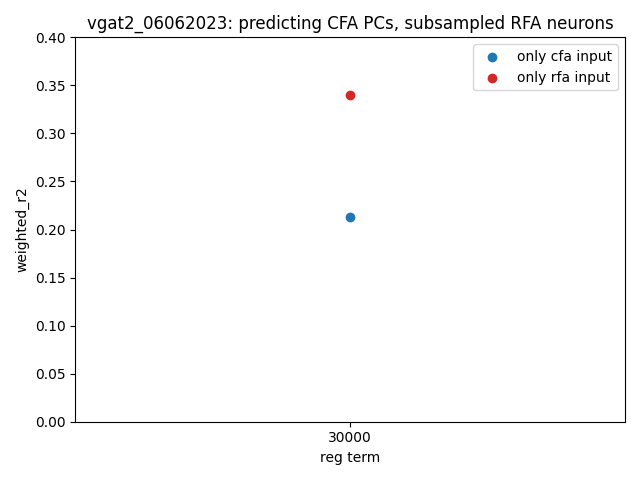

In [15]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session2.X_CFA, session2.Y_CFA, C=c)
    h_rfa = train_wiener_filter(session2.X_RFA, session2.Y_CFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session2.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session2.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session2.Y_CFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session2.Y_CFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig12, ax12 = plt.subplots()
ax12.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax12.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax12.set_title(f'{session2.name}: predicting CFA PCs, subsampled RFA neurons')
ax12.set_ylim([0,.4])
ax12.set_xlabel('reg term')
ax12.set_ylabel('weighted_r2')
ax12.legend()
fig12.tight_layout()



/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


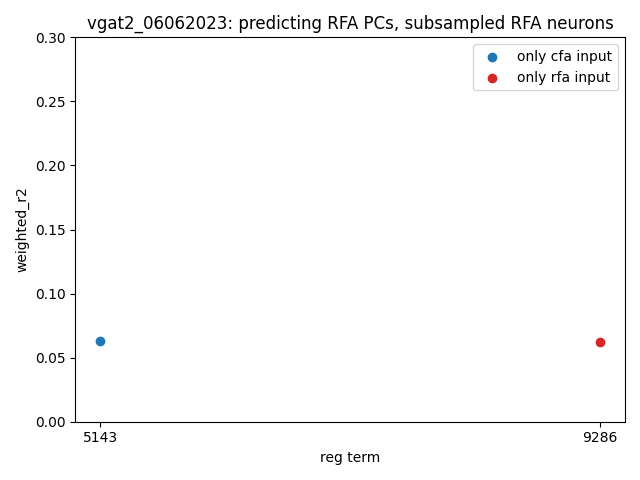

In [16]:
C_list = np.linspace(1000, 30000, 8)
max_cfa_score = 0
max_cfa_reg = 0
max_rfa_score = 0
max_rfa_reg = 0
for c in C_list:
    h_cfa = train_wiener_filter(session2.X_CFA, session2.Y_RFA, C=c)
    h_rfa = train_wiener_filter(session2.X_RFA, session2.Y_RFA, C=c)
    predic_cfa_ctrl = test_wiener_filter(session2.X_CFA_ctrl, h_cfa)
    predic_rfa_ctrl = test_wiener_filter(session2.X_RFA_ctrl, h_rfa)
    cfa_score = weighted_r2(session2.Y_RFA_ctrl, predic_cfa_ctrl)
    rfa_score = weighted_r2(session2.Y_RFA_ctrl, predic_rfa_ctrl)
    if cfa_score > max_cfa_score:
        max_cfa_score = cfa_score
        max_cfa_reg = c
    if rfa_score > max_rfa_score:
        max_rfa_score = rfa_score
        max_rfa_reg = c

fig13, ax13 = plt.subplots()
ax13.scatter(f'{round(max_cfa_reg)}', max_cfa_score, c='tab:blue', label='only cfa input')
ax13.scatter(f'{round(max_rfa_reg)}', max_rfa_score, c='tab:red', label='only rfa input')
ax13.set_title(f'{session2.name}: predicting RFA PCs, subsampled RFA neurons')
ax13.set_ylim([0,.3])
ax13.set_xlabel('reg term')
ax13.set_ylabel('weighted_r2')
ax13.legend()
fig13.tight_layout()



# 2. wider sweep, only keep properly regularized models

In [29]:
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegs9.pickle')

In [39]:
ratio_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []
fit_score_list = []
raw_weights_list = []
for idx, o in enumerate(output):
    h = o[0]
    laser_score = o[1]
    ctrl_score = o[2]
    fit_score = o[3]
    
    temp = session.weights_per_region(h)
    raw_weights_list.append(temp)
    ratio = np.log10(temp[0]/temp[1])
    

    
    if abs(laser_score - fit_score) < 1000:
        if laser_score > 0:
                ratio_list.append(ratio)
                h_list.append(h)
                laser_score_list.append(laser_score)
                ctrl_score_list.append(ctrl_score)
                fit_score_list.append(fit_score)
                
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
ratio_list = np.array(ratio_list)

In [40]:
nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

reg_keep=[]
laser_score_keep = []
ctrl_score_keep = []
ratio_keep = []
fit_score_keep = []
raw_weights_keep = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(laser_score_list[indices])
    temp1 = laser_score_list[indices]
    temp2 = temp1[keep]
    laser_score_keep.append(temp2)
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(0.0, 0.2)

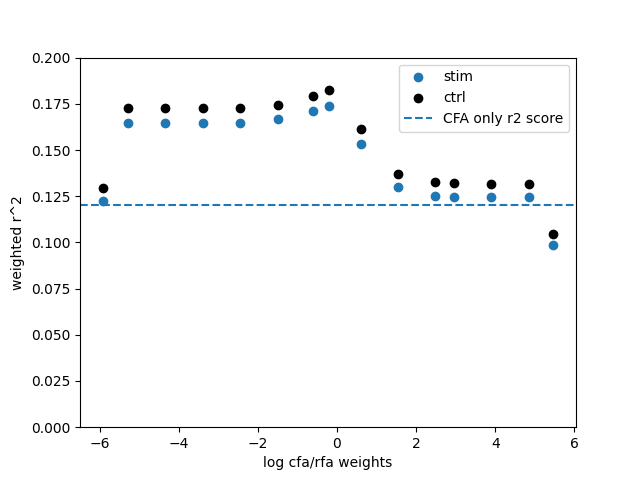

In [41]:
fig2, ax2 = plt.subplots()
ax2.scatter(ratio_keep, laser_score_keep, c='tab:blue', label='stim')
ax2.scatter(ratio_keep, ctrl_score_keep, c='black', label='ctrl')
ax2.set_ylabel('weighted r^2')
ax2.set_xlabel('log cfa/rfa weights')
ax2.axhline(best_CFA_score, c='tab:blue', linestyle='--', label='CFA only r2 score')
ax2.axhline(best_RFA_score, c= 'tab:red', linestyle='--', label='RFA only r2 score')
ax2.legend()

ax2.set_ylim(0, .2)